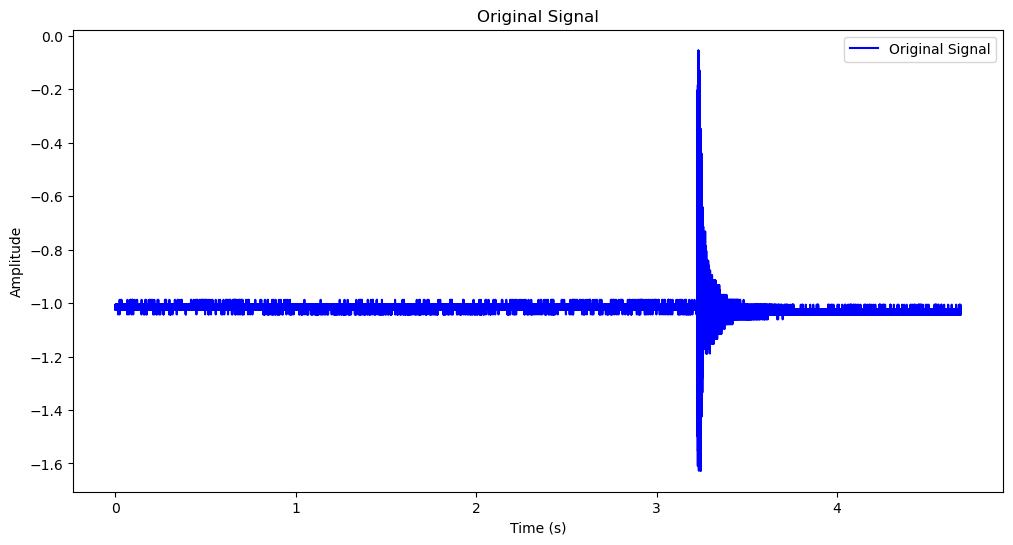

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt

df = pd.read_csv('Waveforms/DATASET_02/TEST3_20_JULY_1533.csv', skiprows=[1])

plt.figure(figsize=(12, 6))
plt.plot(df['Time'], df['Channel A'], label='Original Signal', color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Original Signal')
plt.legend()
plt.show()

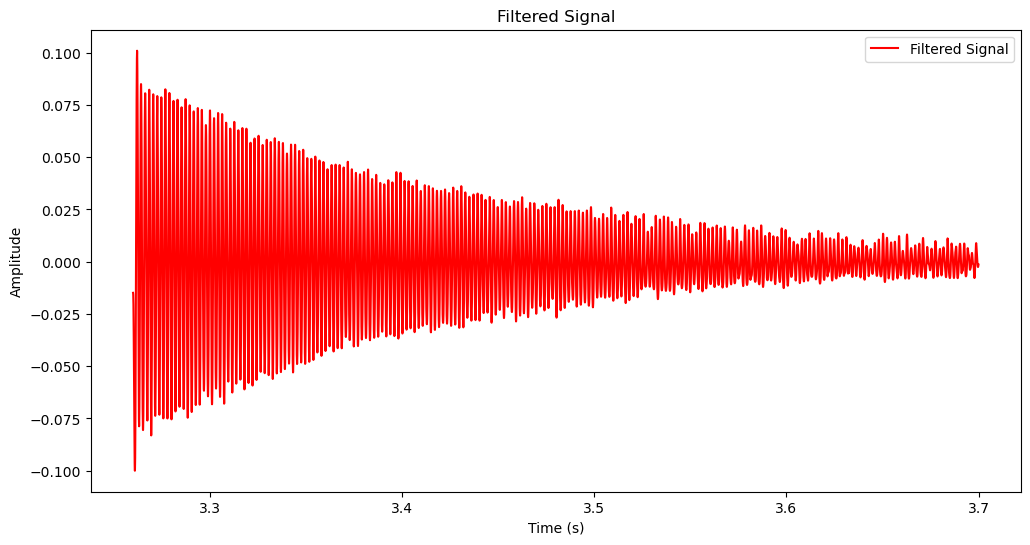

In [18]:
df_slice = df[(df['Time'] >= 3.26) & (df['Time'] <= 3.7)]

time = df_slice['Time'].values
val = df_slice['Channel A'].values

baseline = np.mean(df[(df['Time'] >= 0.5) & (df['Time'] <= 2.0)]['Channel A'].values)
v_detrend = val - baseline

dt = time[1] - time[0]
fs = 1.0 / dt
b, a = butter(2, [200 / (fs/2), 1000 / (fs/2)], btype='band')
v_filtered = filtfilt(b, a, v_detrend)

plt.figure(figsize=(12, 6))
plt.plot(time, v_filtered, label='Filtered Signal', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Filtered Signal')
plt.legend()
plt.show()

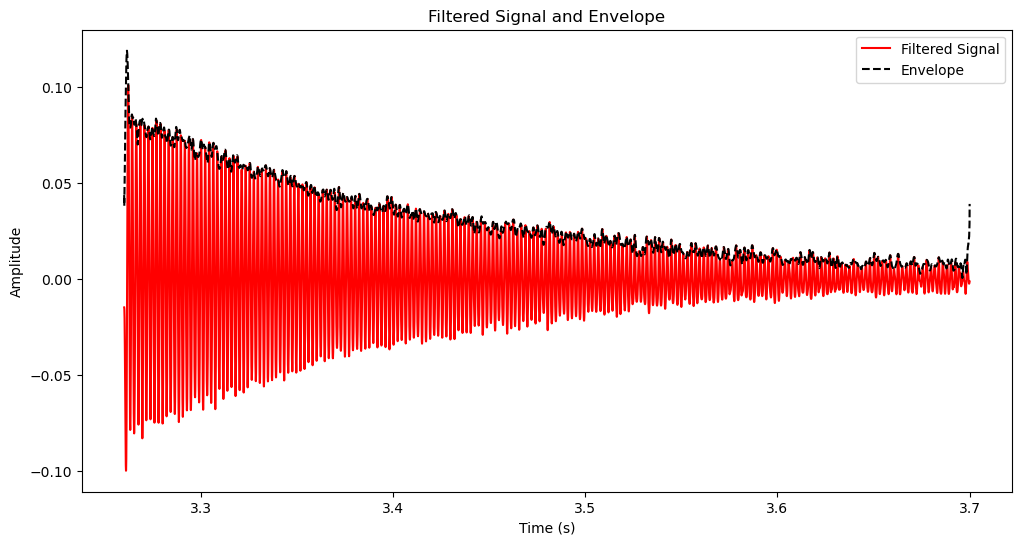

In [19]:
analytic_signal = hilbert(v_filtered)

envelope = np.abs(analytic_signal)

plt.figure(figsize=(12, 6))
plt.plot(time, v_filtered, label='Filtered Signal', color='red')
plt.plot(time, envelope, label='Envelope', color='black', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Filtered Signal and Envelope')
plt.legend()
plt.show()

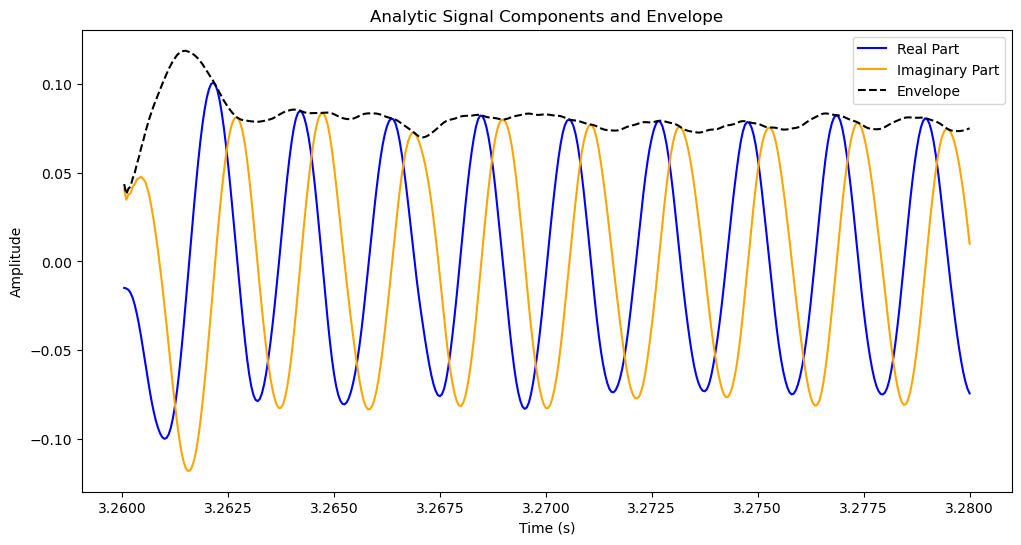

: 

In [ ]:
# change this variable to see the transformed signal down
delimiter = 3.28
sliced_time = time[(time >= 3.26) & (time <= delimiter)]

x_og = np.real(analytic_signal)[(time >= 3.26) & (time <= delimiter)]

x_imag = np.imag(analytic_signal)[(time >= 3.26) & (time <= delimiter)]

envelope = np.sqrt(x_og**2 + x_imag**2)

plt.figure(figsize=(12, 6))
plt.plot(sliced_time, x_og, label='Real Part', color='blue')
plt.plot(sliced_time, x_imag, label='Imaginary Part', color='orange')
plt.plot(sliced_time, envelope, label='Envelope', color='black', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Analytic Signal Components and Envelope')
plt.legend()
plt.show()

#### How does the $scipy.signal.hilbert()$ function works?

